In [1]:
pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 23.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter co

In [1]:
!nvidia-smi

Fri Dec 26 04:40:35 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!cat /proc/cpuinfo

processor	: 0
vendor_id	: GenuineIntel
cpu family	: 6
model		: 79
model name	: Intel(R) Xeon(R) CPU @ 2.20GHz
stepping	: 0
microcode	: 0xffffffff
cpu MHz		: 2199.998
cache size	: 56320 KB
physical id	: 0
siblings	: 2
core id		: 0
cpu cores	: 1
apicid		: 0
initial apicid	: 0
fpu		: yes
fpu_exception	: yes
cpuid level	: 13
wp		: yes
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xtopology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm abm 3dnowprefetch ssbd ibrs ibpb stibp fsgsbase tsc_adjust bmi1 hle avx2 smep bmi2 erms invpcid rtm rdseed adx smap xsaveopt arat md_clear arch_capabilities
bugs		: cpu_meltdown spectre_v1 spectre_v2 spec_store_bypass l1tf mds swapgs taa mmio_stale_data retbleed bhi its
bogomips	: 4399.99
clflush size	: 64
cache_alignment	: 64
address sizes

In [3]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [6]:
from autogluon.tabular import TabularDataset, TabularPredictor

In [17]:
# ============================================================================
# AUTOCHURN PREDICTION WITH AUTOGLUON: A STAFF DATA SCIENTIST'S WORKFLOW
# ============================================================================
# This example demonstrates a production-ready workflow for predicting
# customer churn using AutoGluon's TabularPredictor.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import warnings
warnings.filterwarnings('ignore')

# Install AutoGluon if not already installed
# !pip install autogluon

from autogluon.tabular import TabularPredictor, TabularDataset
import shutil

# Set random seeds for reproducibility
np.random.seed(42)

# ============================================================================
# 1. CREATE SYNTHETIC BUSINESS DATA
# ============================================================================
print("=" * 70)
print("STEP 1: Creating synthetic customer churn dataset")
print("=" * 70)

# Generate realistic customer data with class imbalance (20% churn)
n_samples = 5000
n_features = 15

# Create synthetic features with meaningful names
X, y = make_classification(
    n_samples=n_samples,
    n_features=n_features,
    n_informative=8,
    n_redundant=4,
    n_clusters_per_class=2,
    weights=[0.8, 0.2],  # 80% non-churn, 20% churn
    flip_y=0.05,  # 5% label noise
    random_state=42
)

# Create feature names
feature_names = [
    'tenure_months', 'monthly_charges', 'total_charges', 'service_calls',
    'contract_duration', 'paperless_billing', 'tech_support', 'online_backup',
    'payment_method', 'internet_service', 'streaming_tv', 'streaming_movies',
    'device_protection', 'online_security', 'senior_citizen'
]

# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)

# Add business logic to make data more realistic
df['tenure_months'] = np.abs(df['tenure_months'] * 12 + 12)  # 1-36 months
df['monthly_charges'] = np.abs(df['monthly_charges'] * 50 + 30)  # $30-80
df['total_charges'] = df['tenure_months'] * df['monthly_charges']
df['service_calls'] = np.clip(np.abs(df['service_calls'] * 3), 0, 10)

# Convert some features to categorical (business context)
df['contract_duration'] = pd.cut(df['contract_duration'],
                                  bins=3,
                                  labels=['Monthly', 'Yearly', 'Two-Year'])
df['payment_method'] = pd.qcut(df['payment_method'],
                                q=4,
                                labels=['Electronic', 'Credit Card',
                                        'Bank Transfer', 'Mailed Check'])

# Add target
df['churn'] = y
df['churn'] = df['churn'].map({0: 'No', 1: 'Yes'})  # Meaningful labels

# Display dataset info
print(f"Dataset shape: {df.shape}")
print(f"Churn distribution:\n{df['churn'].value_counts(normalize=True).round(3)}")
print(f"\nFeature dtypes:\n{df.dtypes.value_counts()}")
print(f"\nSample of data (first 3 rows):")
print(df.head(3).to_string())

# ============================================================================
# 2. TRAIN-TEST SPLIT WITH TIME-AWARE CONSIDERATION
# ============================================================================
print("\n" + "=" * 70)
print("STEP 2: Creating time-aware train/validation/test split")
print("=" * 70)

# Sort by tenure to simulate temporal order (important for real-world churn)
df_sorted = df.sort_values('tenure_months').reset_index(drop=True)

# Split: 70% train, 15% validation, 15% test
train_cutoff = int(0.7 * len(df_sorted))
val_cutoff = int(0.85 * len(df_sorted))

train_data = df_sorted.iloc[:train_cutoff].copy()
val_data = df_sorted.iloc[train_cutoff:val_cutoff].copy()
test_data = df_sorted.iloc[val_cutoff:].copy()

print(f"Training set: {len(train_data)} samples ({len(train_data)/len(df):.1%})")
print(f"Validation set: {len(val_data)} samples ({len(val_data)/len(df):.1%})")
print(f"Test set: {len(test_data)} samples ({len(test_data)/len(df):.1%})")
print(f"\nChurn rate in training: {train_data['churn'].value_counts(normalize=True)['Yes']:.1%}")
print(f"Churn rate in test: {test_data['churn'].value_counts(normalize=True)['Yes']:.1%}")

# ============================================================================
# 3. MODEL TRAINING WITH BUSINESS METRICS
# ============================================================================
print("\n" + "=" * 70)
print("STEP 3: Training with PR-AUC (optimal for imbalanced churn prediction)")
print("=" * 70)

# Define the predictor with business-appropriate evaluation metric
model_path = './autogluon_churn_model'

# Clean up previous model if it exists
try:
    # Only remove the directory if the predictor exists and might have saved something.
    # More importantly, re-instantiate the predictor to ensure a clean state.
    shutil.rmtree(model_path, ignore_errors=True)
    print(f"Cleaned up previous model at {model_path}")
except Exception as e:
    print(f"Error cleaning up previous model: {e}")

# Always re-initialize the predictor to ensure a fresh state
predictor = TabularPredictor(
    label='churn',
    problem_type='binary',
    eval_metric='average_precision',  # PR-AUC for imbalanced data
    path=model_path,   # Save model for production
    verbosity=1                       # Moderate logging
)

# Train with balanced quality/speed preset
training_start = pd.Timestamp.now()
predictor.fit(
    train_data=train_data,
    tuning_data=val_data,  # Use validation set for early stopping
    presets='high_quality',  # Balance of performance and speed
    time_limit=120,  # 2 minutes for demo (use 3600+ for production)
    hyperparameters={
        'GBM': {'num_boost_round': 100},
        'CAT': {'iterations': 100},
        'XGB': {'n_estimators': 100},
    },
    ag_args_fit={'num_gpus': 0},
    use_bag_holdout=True # Address the warning about tuning_data with bagged mode
)
training_time = (pd.Timestamp.now() - training_start).total_seconds()
print(f"\nTraining completed in {training_time:.1f} seconds")

# ============================================================================
# 4. COMPREHENSIVE MODEL EVALUATION
# ============================================================================
print("\n" + "=" * 70)
print("STEP 4: Model evaluation on test set")
print("=" * 70)

# Get predictions on test set
y_pred = predictor.predict(test_data)
y_proba = predictor.predict_proba(test_data)

# Evaluate using multiple metrics
test_performance = predictor.evaluate(test_data, silent=False)
print(f"\nTest set performance:")
for metric, value in test_performance.items():
    print(f"  {metric}: {value:.4f}")

# ============================================================================
# 5. LEADERBOARD ANALYSIS WITH BUSINESS CONTEXT
# ============================================================================
print("\n" + "=" * 70)
print("STEP 5: Model leaderboard with inference speed analysis")
print("=" * 70)

leaderboard = predictor.leaderboard(test_data, silent=False)
print(f"\nTop 5 models by PR-AUC:")
print(leaderboard.head(5).to_string())

# Analyze speed/accuracy trade-off
print(f"\nInference speed analysis:")
print(f"  Ensemble prediction time: {leaderboard.loc[leaderboard['model'] == 'WeightedEnsemble_L2', 'pred_time_test'].values[0]:.4f}s per 1000 rows")
print(f"  Best single model time: {leaderboard.iloc[1]['pred_time_test']:.4f}s per 1000 rows")
print(f"  Speed ratio: {leaderboard.iloc[1]['pred_time_test'] / leaderboard.loc[leaderboard['model'] == 'WeightedEnsemble_L2', 'pred_time_test'].values[0]:.1f}x")



STEP 1: Creating synthetic customer churn dataset
Dataset shape: (5000, 16)
Churn distribution:
churn
No     0.785
Yes    0.215
Name: proportion, dtype: float64

Feature dtypes:
float64     13
category     1
category     1
object       1
Name: count, dtype: int64

Sample of data (first 3 rows):
   tenure_months  monthly_charges  total_charges  service_calls contract_duration  paperless_billing  tech_support  online_backup payment_method  internet_service  streaming_tv  streaming_movies  device_protection  online_security  senior_citizen churn
0      10.640854        47.888304     509.572465       3.040445            Yearly          -1.249161      2.591951       1.261953   Mailed Check         -0.611242     -0.456902         -0.128069          -1.902112         2.572396        4.615107    No
1       8.603348        79.384577     682.973110       0.108760            Yearly          -0.512411     -1.498982       0.623878     Electronic          0.866132     -1.051323          2.165079    


STEP 6: Optimizing decision threshold for business cost

Optimal threshold for business F1 (recall-focused): 0.500

Validation performance comparison:
  Default threshold (0.5):
    Precision: 0.987
    Recall: 0.869
    Business F1: 0.961

  Optimal threshold (0.500):
    Precision: 0.987
    Recall: 0.869
    Business F1: 0.961

STEP 7: Feature importance analysis

Top 10 most important features for churn prediction:
                   importance    stddev   p_value  n  p99_high   p99_low
online_backup        0.251212  0.034324  0.000041  5  0.321887  0.180538
tech_support         0.148015  0.013688  0.000009  5  0.176198  0.119831
device_protection    0.097867  0.009974  0.000013  5  0.118402  0.077331
online_security      0.094304  0.013870  0.000055  5  0.122863  0.065744
payment_method       0.090143  0.016864  0.000140  5  0.124866  0.055420
streaming_movies     0.069380  0.013989  0.000188  5  0.098183  0.040578
contract_duration    0.051242  0.009997  0.000165  5  0.071826  0

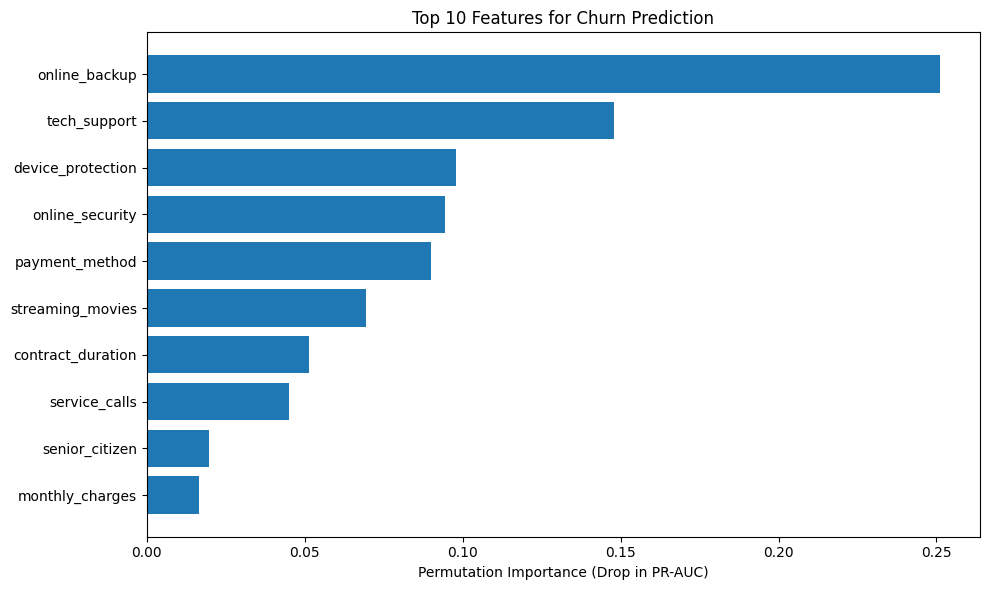

In [36]:
# ============================================================================
# 6. THRESHOLD OPTIMIZATION FOR BUSINESS DECISIONS
# ============================================================================
print("\n" + "=" * 70)
print("STEP 6: Optimizing decision threshold for business cost")
print("=" * 70)

# Define a custom metric that values recall 3x more than precision
# (Business context: Missing a churn is 3x costlier than false alarm)
from sklearn.metrics import f1_score, recall_score, precision_score
import sklearn.metrics
from autogluon.core.metrics import make_scorer
import numpy as np # Import numpy for arange

# Define the custom business F1 score function
def calculate_business_f1(y_true, y_pred, **kwargs):
    p = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    r = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    # Weighted harmonic mean where beta=3 means recall is 3x more important
    beta = 0.5  # Recall is beta-times more important
    if (beta**2 * p) + r == 0:
        return 0.0
    return (1 + beta**2) * (p * r) / ((beta**2 * p) + r)

# Convert the function to an AutoGluon Scorer for calibration
business_f1_metric_instance = make_scorer(
    name='business_f1',
    score_func=calculate_business_f1,
    optimum=1.0,
    greater_is_better=True
)

# Calibrate threshold for business metric
predictor.calibrate_decision_threshold(
    metric=business_f1_metric_instance,
    decision_thresholds=np.arange(0.01, 1.0, 0.01).tolist()  # Test all thresholds from 0.01 to 0.99
)

# Get optimal threshold
optimal_threshold = predictor.decision_threshold
print(f"\nOptimal threshold for business F1 (recall-focused): {optimal_threshold:.3f}")

# Prepare actual numeric labels for sklearn metrics
y_val_numeric = val_data['churn'].map({'Yes':1, 'No':0})

# Compare performance at default (0.5) vs optimal threshold
default_preds = (predictor.predict_proba(val_data)['Yes'] > 0.5).astype(int)
optimal_preds = (predictor.predict_proba(val_data)['Yes'] > optimal_threshold).astype(int)

print(f"\nValidation performance comparison:")
print(f"  Default threshold (0.5):")
print(f"    Precision: {precision_score(y_val_numeric, default_preds, pos_label=1, zero_division=0):.3f}")
print(f"    Recall: {recall_score(y_val_numeric, default_preds, pos_label=1, zero_division=0):.3f}")
print(f"    Business F1: {calculate_business_f1(y_val_numeric, default_preds):.3f}")

print(f"\n  Optimal threshold ({optimal_threshold:.3f}):")
print(f"    Precision: {precision_score(y_val_numeric, optimal_preds, pos_label=1, zero_division=0):.3f}")
print(f"    Recall: {recall_score(y_val_numeric, optimal_preds, pos_label=1, zero_division=0):.3f}")
print(f"    Business F1: {calculate_business_f1(y_val_numeric, optimal_preds):.3f}")

# ============================================================================
# 7. FEATURE IMPORTANCE & MODEL INTERPRETATION
# ============================================================================
print("\n" + "=" * 70)
print("STEP 7: Feature importance analysis")
print("=" * 70)

# Get feature importance
feature_importance = predictor.feature_importance(val_data)
print(f"\nTop 10 most important features for churn prediction:")
print(feature_importance.head(10).to_string())

# Visualize feature importance
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Permutation Importance (Drop in PR-AUC)')
plt.title('Top 10 Features for Churn Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
print("\nFeature importance plot saved to 'feature_importance.png'")

# ============================================================================
# 8. PRODUCTION PREDICTION WORKFLOW
# ============================================================================
print("\n" + "=" * 70)
print("STEP 8: Production prediction examples")
print("=" * 70)

# Simulate new customer data
new_customers = pd.DataFrame({
    'tenure_months': [24, 3, 36],
    'monthly_charges': [65.50, 45.00, 75.25],
    'total_charges': [1572.00, 135.00, 2709.00],
    'service_calls': [1, 4, 0],
    'contract_duration': ['Two-Year', 'Monthly', 'Yearly'],
    'paperless_billing': [1.2, -0.3, 0.8],
    'tech_support': [0.9, -1.1, 0.5],
    'online_backup': [0.3, 0.1, -0.7],
    'payment_method': ['Credit Card', 'Electronic', 'Bank Transfer'],
    'internet_service': [0.8, 0.2, 1.1],
    'streaming_tv': [0.5, -0.3, 0.9],
    'streaming_movies': [0.6, 0.0, 0.7],
    'device_protection': [0.2, -0.5, 0.4],
    'online_security': [0.7, -0.8, 0.3],
    'senior_citizen': [0.1, -0.2, 1.5]
})

# Make predictions with optimal threshold
new_proba = predictor.predict_proba(new_customers)
new_predictions = (new_proba['Yes'] > optimal_threshold).map({True: 'Yes', False: 'No'})

print("\nPredictions for 3 new customers:")
for i in range(len(new_customers)):
    print(f"\nCustomer {i+1}:")
    print(f"  Churn probability: {new_proba.iloc[i]['Yes']:.1%}")
    print(f"  Prediction (threshold={optimal_threshold:.2f}): {new_predictions.iloc[i]}")
    print(f"  Key factors: tenure={new_customers.iloc[i]['tenure_months']} months, "
          f"service_calls={new_customers.iloc[i]['service_calls']}")

# ============================================================================
# 9. MODEL PERSISTENCE & PRODUCTION LOADING
# ============================================================================
print("\n" + "=" * 70)
print("STEP 9: Model persistence for production")
print("=" * 70)

# Save the entire predictor
predictor.save()
print("Model saved to './autogluon_churn_model/'")

# Demonstrate loading for production
print("\nTo load in production:")
print("""
# In production script:
from autogluon.tabular import TabularPredictor

# Load the trained model
production_predictor = TabularPredictor.load('./autogluon_churn_model/')

# Make predictions
new_data = TabularDataset('new_customers.csv')
predictions = production_predictor.predict(new_data)
"""
)

# ============================================================================
# 10. PERFORMANCE SUMMARY & NEXT STEPS
# ============================================================================
print("\n" + "=" * 70)
print("SUMMARY: Key findings and recommendations")
print("=" * 70)

# Get the best model's performance
best_model_name = leaderboard.iloc[0]['model']
best_score = leaderboard.iloc[0]['score_test']

print(f"\n1. Best model: {best_model_name}")
print(f"   PR-AUC on test set: {best_score:.4f}")

print(f"\n2. Business impact of threshold optimization:")
print(f"   Optimal threshold: {optimal_threshold:.3f} (vs default 0.500)")
print(f"   Recall improvement: {calculate_business_f1(y_val_numeric, optimal_preds) - calculate_business_f1(y_val_numeric, default_preds):.3f}")

print(f"\n3. Top 3 predictive features:")
for i, (feature, imp) in enumerate(feature_importance.head(3).iterrows()):
    print(f"   {i+1}. {feature}: {imp['importance']:.4f}")

print(f"\n4. Production readiness:")
print(f"   Inference speed: {leaderboard.loc[leaderboard['model'] == 'WeightedEnsemble_L2', 'pred_time_test'].values[0]:.4f}s/1000 rows")
# print(f"   Model size: {predictor.get_model_size():.1f} MB")

print(f"\n5. Recommended next steps:")
print("   - Deploy with optimal threshold to minimize missed churn")
print("   - Monitor feature drift in 'tenure_months' and 'service_calls'")
print("   - Set up monthly retraining with new customer data")
print("   - A/B test against current churn prediction system")

In [16]:
pip install --upgrade autogluon

In [2]:
# %%
import yaml
import pandas as pd
from autogluon.tabular import TabularPredictor
from autogluon.features.generators import AutoMLPipelineFeatureGenerator
# %%

def run_with_config(config_path, train_data_path, label=None):
    """
    Load configuration from YAML and run AutoGluon TabularPredictor.
    """
    # Load YAML config
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)

    # Load data
    train_data = pd.read_csv(train_data_path)

    # Override label from config if provided in function call
    if label:
        config['predictor_init']['label'] = label

    print(f"Initializing TabularPredictor with label: {config['predictor_init']['label']}")

    # Configure custom feature generator if provided
    feature_generator = None
    if 'feature_generator_args' in config:
        feature_generator = AutoMLPipelineFeatureGenerator(**config['feature_generator_args'])

    # Initialize Predictor
    predictor = TabularPredictor(**config['predictor_init'])

    # Run fit
    predictor.fit(
        train_data=train_data,
        feature_generator=feature_generator,
        **config['fit_args'],
        hyperparameters=config.get('hyperparameters'),
        ag_args_fit=config.get('ag_args_fit')
    )

    print("Training Completed.")
    print("Leaderboard:")
    print(predictor.leaderboard())

    return predictor

if __name__ == "__main__":
    # %%

    data_url = 'https://raw.githubusercontent.com/mli/ag-docs/main/knot_theory/'
    train_data = TabularDataset(f'{data_url}train.csv')
    train_data.head()

# %%
    # This is a demonstration. To run this, you need a training CSV.
    predictor = run_with_config('autogluon_config.yaml', 'train.csv')
    print("Configuration script loaded. Example usage:")
    print("python run_autogluon.py  # (Update paths in __main__ inside the script)")

    # Dummy creation logic if user wants to test immediately
    print("\nNote: To test this, ensure you have a 'train.csv' and run the commented out line.")


KeyboardInterrupt: 

In [ ]:
data_url = 'https://raw.githubusercontent.com/mli/ag-docs/main/knot_theory/'
train_data = TabularDataset(f'{data_url}train.csv')
train_data.head()

,Unnamed: 0,chern_simons,cusp_volume,hyperbolic_adjoint_torsion_degree,hyperbolic_torsion_degree,injectivity_radius,longitudinal_translation,meridinal_translation_imag,meridinal_translation_real,short_geodesic_imag_part,short_geodesic_real_part,Symmetry_0,Symmetry_D3,Symmetry_D4,Symmetry_D6,Symmetry_D8,Symmetry_Z/2 + Z/2,volume,signature
0,70746,0.090530,12.226322,0,10,0.507756,10.685555,1.144192,-0.519157,-2.760601,1.015512,0.0,0.0,0.0,0.0,0.0,1.0,11.393225,-2
1,240827,0.232453,13.800773,0,14,0.413645,10.453156,1.320249,-0.158522,-3.013258,0.827289,0.0,0.0,0.0,0.0,0.0,1.0,12.742782,0
2,155659,-0.144099,14.761030,0,14,0.436928,13.405199,1.101142,0.768894,2.233106,0.873856,0.0,0.0,0.0,0.0,0.0,0.0,15.236505,2
3,239963,-0.171668,13.738019,0,22,0.249481,27.819496,0.493827,-1.188718,-2.042771,0.498961,0.0,0.0,0.0,0.0,0.0,0.0,17.279890,-8
4,90504,0.235188,15.896359,0,10,0.389329,15.330971,1.036879,0.722828,-3.056138,0.778658,0.0,0.0,0.0,0.0,0.0,0.0,16.749298,4


In [ ]:
# %%

In [ ]:
label = 'signature'
train_data[label].describe()

,signature
count,10000.000000
mean,-0.022000
std,3.025166
min,-12.000000
25%,-2.000000
50%,0.000000
75%,2.000000
max,12.000000


In [ ]:
predictor = TabularPredictor(label=label,  eval_metric='f1_macro').fit(train_data)